COLAB C — PyTorch Class-Based 3-Layer Deep Neural Network

Cell 1 — Install and Imports

In [9]:
!pip install torch torchvision scikit-learn matplotlib --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(42)
np.random.seed(42)

Cell 2 — Generate Synthetic 3-Variable Nonlinear Data

We use the same nonlinear function:
y=sin(x1​)+x22​+log(x32​+1)

In [10]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y).view(-1, 1)

print("Input shape:", X_tensor.shape)
print("Output shape:", y_tensor.shape)

Input shape: torch.Size([1000, 3])
Output shape: torch.Size([1000, 1])


Cell 3 — Define 3-Layer Deep Neural Network (Class-Based)

Architecture:

Input: 3

Hidden 1: 64 neurons (ReLU)

Hidden 2: 32 neurons (Tanh)

Hidden 3: 16 neurons (ReLU)

Output: 1 neuron (Linear)

In [11]:
class DeepRegressionNet(nn.Module):
    def __init__(self):
        super(DeepRegressionNet, self).__init__()

        self.layer1 = nn.Linear(3, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = self.output(x)
        return x

Cell 4 — Initialize Model, Loss, Optimizer

In [12]:
model = DeepRegressionNet()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

DeepRegressionNet(
  (layer1): Linear(in_features=3, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


Cell 5 — Training Loop (Built-in Backprop)

In [13]:
epochs = 500
losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    loss.backward()  # automatic backpropagation
    optimizer.step()

    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 6.808849
Epoch 50, Loss: 1.776483
Epoch 100, Loss: 0.994687
Epoch 150, Loss: 0.436216
Epoch 200, Loss: 0.191029
Epoch 250, Loss: 0.102046
Epoch 300, Loss: 0.049860
Epoch 350, Loss: 0.033287
Epoch 400, Loss: 0.024677
Epoch 450, Loss: 0.018450


Cell 6 — Plot Training Loss

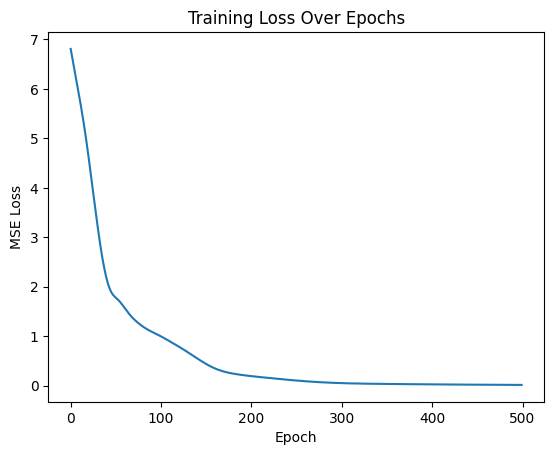

In [14]:
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Cell 7 — True vs Predicted Scatter Plot

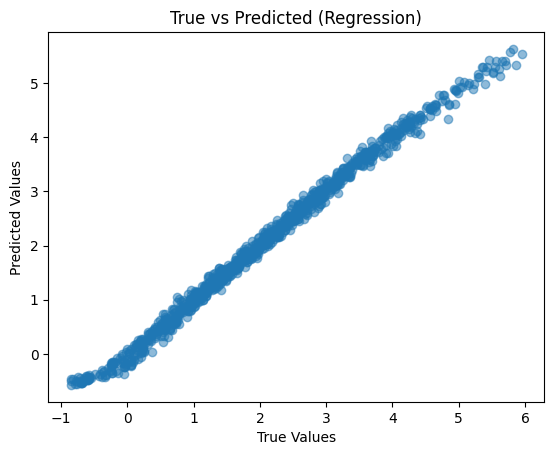

In [15]:
model.eval()
with torch.no_grad():
    preds = model(X_tensor)

plt.scatter(y, preds.numpy(), alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted (Regression)")
plt.show()

🔹 Cell 8 — 4D Visualization (3 Inputs + Output)

We reduce 3D input into 2D using PCA for visualization.

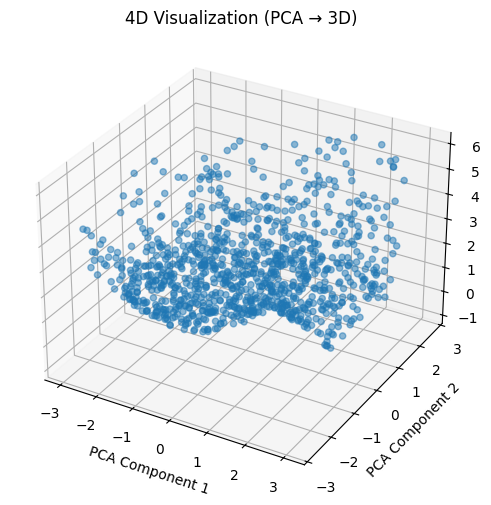

In [16]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Output")
plt.title("4D Visualization (PCA → 3D)")
plt.show()